# Tutorial for `mypackage`

This package can be used to mainly analyse datasets (correlation, relations, distributions etc.) and also visualize them accordingly.
This package used the "Titanic" dataset offered by "seaborn".

To get started, we first identify the environment associated with our package and activate it.
>We have to be in the right environment to use the package!

After we activated the right environment, we can use `!conda info` to doublecheck whether we are in the right environment.

In [1]:
%pip list

Package                       Version     Editable project location
----------------------------- ----------- ----------------------------------------------------------------------------
aiohappyeyeballs              2.4.4
aiohttp                       3.11.10
aiosignal                     1.2.0
alabaster                     0.7.16
anyio                         4.6.2
applaunchservices             0.3.0
appnope                       0.1.3
argon2-cffi                   21.3.0
argon2-cffi-bindings          21.2.0
arrow                         1.3.0
astroid                       3.3.8
asttokens                     2.0.5
async-lru                     2.0.4
asyncssh                      2.17.0
atomicwrites                  1.4.0
attrs                         24.3.0
autopep8                      2.0.4
babel                         2.16.0
backcall                      0.2.0
beautifulsoup4                4.12.3
binaryornot                   0.4.4
black                         24.10.0
bleach    

In [1]:
%conda info


     active environment : mypackage-env
    active env location : /Users/can/anaconda3/envs/mypackage-env
            shell level : 3
       user config file : /Users/can/.condarc
 populated config files : /Users/can/.condarc
          conda version : 24.11.3
    conda-build version : 25.1.2
         python version : 3.11.5.final.0
                 solver : libmamba (default)
       virtual packages : __archspec=1=m2
                          __conda=24.11.3=0
                          __osx=15.3.2=0
                          __unix=0=0
       base environment : /Users/can/anaconda3  (writable)
      conda av data dir : /Users/can/anaconda3/etc/conda
  conda av metadata url : None
           channel URLs : https://repo.anaconda.com/pkgs/main/osx-arm64
                          https://repo.anaconda.com/pkgs/main/noarch
                          https://repo.anaconda.com/pkgs/r/osx-arm64
                          https://repo.anaconda.com/pkgs/r/noarch
          package cache : /Users/

## Now we can finally import our package!

At first, we import our two python files containing the analysis and the visualization of the analysis.

In [2]:
from mypackage.analysis import data, Analyzer
from mypackage.visualization import data, Visualizer

We can now initialize the classes with the data and assign them to new variables which makes it easier to access their functions.

In [3]:
analyzer = Analyzer(data)
visualizer = Visualizer(data)

## What do the two classes actually do?

In [6]:
print(analyzer.__doc__)

The Analyzer class provides methods for statistical and categorical
    analyses of the Titanic dataset.
    
    
    Attributes
    ----------
    data: pandas.DataFrame
        The Titanic dataset that is going to be analyzed.
    
    


In [5]:
print(visualizer.__doc__)

Visualizer creates visualizations of the analyzed data through the 'Analyzer' class.
    It includes methods for plotting distributions, generating heatmaps and
    creating scatterplots.
    
    
    Attributes
    ----------
    data: pandas.DataFrame
        The Titanic dataset that is going to be analyzed.
    
    


## Now we can have a look at the different functions within our classes!
We will start with the `Analyzer` class and its functions.

In the beginning, we initialize the class instance with the given dataset (Titanic). 

We also add some control mechanisms (assertion checks) to ensure that the methods actually work. 

In [ ]:
def __init__(self, data):
        
    # check if the dataset is stored as a pandas DataFrame
    assert isinstance(data, pd.DataFrame), ("Data must be a pandas DataFrame")
    # ensure that the dataset is not empty
    assert not data.empty, "The dataset must not be empty."
        
    self.data = data

If you want further information on what the method does, you can use the `help()` function to view its explanation.

In [8]:
help(Analyzer.__init__)

Help on function __init__ in module mypackage.analysis:

__init__(self, data)
    Initializes the class instance with the given (Titanic) dataset


    Parameters
    ----------
    data: pandas.DataFrame
        The Titanic dataset that is going to be analyzed.



### Statistics
The `get_stats` method gives us all the necessary statistical information about a column of the dataset, using the `.describe()` function.

In [ ]:
def get_stats(self, column: str):
    
    # check if the passed column exists in the dataset
    assert column in self.data.columns, f"Column '{column}' does not exist in the dataset."
        
    # get the most important statistic through the .descibe function
    return self.data[column].describe()

##### Parameters:
- column: str  
The name of the column to analyze. This should be a name of one of the columns in the Titanic dataset.

##### Returns
pandas.Series:
- A Series containing basic statistics about the specific column.
- including mean, standard deviation, quantiles etc.

In [ ]:
analyzer.get_stats(column= "age")

count    891.000000
mean      30.295365
std       13.058707
min        0.420000
25%       22.000000
50%       32.000000
75%       35.000000
max       80.000000
Name: age, dtype: float64

### Relationship between two categorical variables.

The `chi_square_test` function helps us analyze the relationship between two categorical variables.

In [ ]:
def chi_square_test(self, column1: str, column2: str):
    
    # check if the passed columns exist in the dataset
    assert column1 in self.data.columns, f"Column '{column1}' does not exist in the dataset."
    assert column2 in self.data.columns, f"Column '{column2}' does not exist in the dataset."
        
    # Create a contingency table for the two specified columns
    contingency_table = pd.crosstab(self.data[column1], self.data[column2])
        
    assert not contingency_table.empty, "Contingency table must not be empty."
        
    # Perform chi-square test to assess the independence between the two variables.
    # This returns the chi-square statistic, p-value, degrees of freedom, and the expected frequencies.
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    # Calculate Cramér's V, which provides a measure of association between the two categorical variables.
    v = self.cramers_v(chi2, contingency_table)

    alpha = 0.05
    # Determine if the result is statistically significant based on the p-value
    if p < alpha: print(f"There is a statistically significant relationship between {column1} and {column2}")
    else: print(f"\n There is no significant relationship between {column1} and {column2} \n")
       
    # Return the chi-square statistic, p-value, and Cramér's V for further analysis or reporting.
    return chi2, p, v

##### Parameters:
- column1: str
- column2: str

The passed columns/variables need to be strings otherwise this function will not work properly!

##### Returns
chi2: float

- The Chi-Square statistic which measures the difference between observed and expected frequencies.

p: float

- The p-value indicating statistical significance.

v: float

- Cramer's V value which measures the strength of association between the two variables.

#### Notes
 The Chi-Square test is only used for categorical variables.

- A p-value < 0.05 indicates a statistically significant relationship between the two categorical variables.
- Cramer's V value ranges from 0 to 1. Values close to 0 indicate weak association and values near 1 indicate a strong association.

In [ ]:
print(analyzer.chi_square_test(column1= "age", column2= "survived")) 

There is a statistically significant relationship between age and survived
(np.float64(155.34203137403557), np.float64(9.367766923465157e-06), np.float64(0.4175472598694749))


 ### Cramer's V 
The `cramers_v` to measure the association between
two catgorical variables. It is used for the `chi_square_test`.

In [ ]:
def cramers_v(self, chi2, contingency_table):
    
    # check if chi2 is a numerical value
    assert isinstance(chi2, (float, int)), "The 'chi2' value must be a numeric value."
    # ensure that the contigency table is not empty
    assert contingency_table.size > 0, "Contingency table must not be empty."

    # Calculate the total number of observations in the contingency table.
    n = contingency_table.sum().sum()
    # Compute the degrees of freedom adjustment using the smallest dimension minus one.
    min_dim = min(contingency_table.shape) - 1
    # Return the normalized chi-square statistic as the square root of (chi2 / (n * min_dim))
    return np.sqrt(chi2 / (n * min_dim))

##### Parameters

chi2: float
- The Chi-Square statistic from the contingency table.

contingency_table: pandas.DataFrame
- The contigency table which contains the frequencies for categories of the two categorical variables.

##### Returns

float:
- Cramer's V value which measures the strength of association between the two categorical variables.

#### Notes
Cramer's V value ranges from 0 to 1. 

Values close to 0 indicate weak association and values near 1 indicate a strong association.

This method is used for the Chi-Square test between two categorical variables.

### Avg. fare price per passenger class by embarkation town

The `ccf_categorization_mean` function computes the avergage ticket price paid per class for every embarked town.
The ccf stands for City-Class-Fare.

It groups the data by `embark_town` and `pclass`, then selects the `fare` column for aggregation and calculates the statistics for each group and resets the index to flatten the df. We then pivot the table to have the towns as the index.

In [ ]:
def ccf_categorization_mean(self):
    
    # Group the data by 'embark_town' and 'pclass', then select the 'fare' column for aggregation.
    grouped = self.data.groupby(["embark_town", "pclass"])["fare"]
    # Calculate statistics (mean, min, max, count) for each group and reset the index to flatten the DataFrame.
    grouped_stats = grouped.agg(["mean", "min", "max", "count"]).reset_index()
    # Pivot the table to have 'embark_town' as the index and 'pclass' as the columns, using the mean fare as values.
    pivot_table_mean = grouped_stats.pivot(index='embark_town', columns='pclass', values='mean')
    # Return the pivot table of mean fares.
    return pivot_table_mean

In [10]:
analyzer.ccf_categorization_mean()

pclass,1,2,3
embark_town,,,
Cherbourg,104.718529,25.358335,11.214083
Queenstown,90.000000,12.350000,11.183393
Southampton,70.364862,20.327439,14.644083


### Passenger count by town and class
The `ccf_categorization_count` function computes the passenger count for every passenger class by embarked towns.

Works exactly the same as ccf_categorization_mean but uses the count function instead of the mean function.

In [ ]:
def ccf_categorization_count(self):
    
    # Group the data by 'embark_town' and 'pclass', then select the 'fare' column for aggregation.
    grouped = self.data.groupby(["embark_town", "pclass"])["fare"]
    # Calculate statistics (mean, min, max, count) for each group and reset the index to flatten the DataFrame.
    grouped_stats = grouped.agg(["mean", "min", "max", "count"]).reset_index()
    # Pivot the table to have 'embark_town' as the index and 'pclass' as the columns,
    # using the count function to display passenger count.
    pivot_table_count = grouped_stats.pivot(index='embark_town', columns='pclass', values = 'count')
    return pivot_table_count

In [11]:
analyzer.ccf_categorization_count()

pclass,1,2,3
embark_town,,,
Cherbourg,85,17,66
Queenstown,2,3,72
Southampton,127,164,353


### Survival rates

Computes survival rates grouped by a categorical variable.

In [ ]:
def survival_rate(self, group_by_column: str):
    
    # check if the column used to group the survival rates exists in the dataset
    assert group_by_column in self.data.columns, f"Column '{group_by_column}' does not exist in the dataset."
        
    # Calculate the survival rates by grouping the data by "survived".
    survival_rates = self.data.groupby(group_by_column)["survived"].mean()
    return survival_rates

##### Parameters
group_by_column: str

- The name of the column used to group survival rates. This should be a categorical variable.

In [15]:
analyzer.survival_rate("who")

who
child    0.590361
man      0.163873
woman    0.756458
Name: survived, dtype: float64

## Now to the methods of the Visualizer class!

In the beginning, we initialize the class instance with the given dataset (Titanic).

We also add some control mechanisms (assertion checks) to ensure that the methods actually work.

In [ ]:
def __init__(self, data):
    # check if the dataset is stored as a pandas DataFrame
        assert isinstance(data, pd.DataFrame), ("Data must be a pandas DataFrame")
        
        super().__init__(data)

### Distribution of a numerical variable

Plots the distribution of observations for a numerical variable
using a histogram and a kde curve.

In [ ]:
def distribution_numerical(self, column: str):

    # check if the passed column exists in the dataset
    assert column in self.data.columns, f"Column '{column}' does not exist in the dataset."
        
    plt.figure(figsize = (8,5))  # creates a new figure
    sns.histplot(self.data[column], kde = True, color = "blue")  # generates a histogram with an overlaid kde curve and sets the color to blue
    
    plt.title(f"Distribution of {column}")  # adds a title
    plt.xlabel(column)  # label the x-axis with column name
    plt.ylabel("frequency")  # adds label for the y-axis
    plt.show()  # displays the histogram and the kde curve

##### Parameters:
column: str
- The name of the column to analyze. This should be a name of one of the columns in the Titanic dataset and must represent a numerical variable.

##### Notes:

Although this method can technically be used with categorical variables,
it is designed for numerical variables.

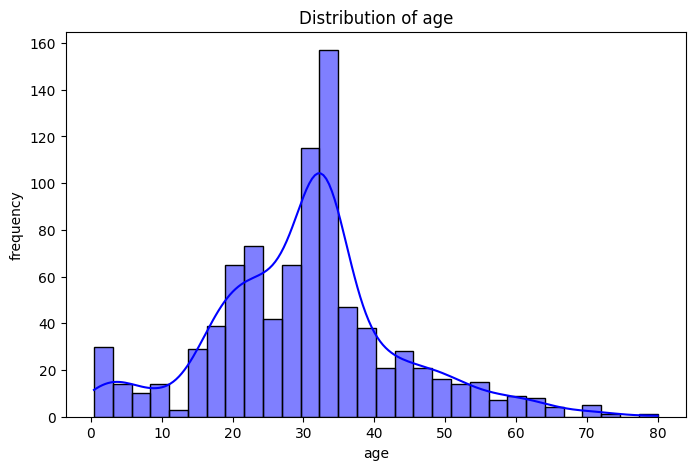

In [17]:
visualizer.distribution_numerical(column = "age")

The distribution of passenger ages on the Titanic is unimodal, peaking around 30 - 35 years old, indicating that most passengers were in their early 30s. There is a noticeable proportion of younger passengers, though fewer in the very young ages, and a gradual decline extending into older age groups. Overall, the histogram is slightly right-skewed, reflecting a smaller number of older passengers.

### Survival Rates

Plots survival rates grouped by a categorical variable as a barplot.

In [ ]:
def plot_survival_rate(self, group_by_column: str):
    
    # check if the column used to group the survival rates exists in the dataset
    assert group_by_column in self.data.columns, f"Column '{group_by_column}' does not exist in the dataset."
        
    # computes survival rates grouped by the specified column
    survival_rates = self.survival_rate(group_by_column)
        
    plt.figure(figsize = (8,5))  # creates a new figure
    survival_rates.sort_values().plot(kind = "bar", color = "darkgrey", alpha = 0.7)
    # plots survival rates as a barplot, sorts values for better visualization
    
    plt.title(f"Survival rates grouped by {group_by_column}")  # adds title
    plt.xlabel(group_by_column)  # adds label to the x-axis
    plt.ylabel("Survival Rate")  # adds label to the y-axis
    
    plt.xticks(rotation = 360)  # rotates labels for better visualization
    plt.ylim((0,1))  # sets limits for the y-axis from 0 to 1 since survival rates are proportions
    plt.show()  # displays the barplot


##### Parameters:
group_by_column: str
- The name of the column used to group survival rates. This should be a categorical variable.

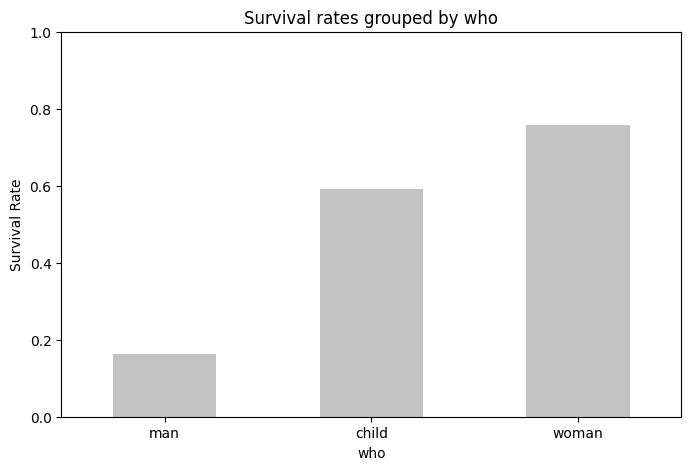

In [19]:
visualizer.plot_survival_rate(group_by_column = "who")

Men had the lowest survival rate, followed by children, while women had the highest survival rate. 

This suggests that women and children were given priority in rescue efforts, resulting in better survival outcomes compared to men.

### Avg. ticket price by class and embarkation town
Creates a heatmap to visualize the average ticket price by embarkation town and passenger class.

In [ ]:
def ccf_mean_heatmap(self):
    
    # generates the pivot table using the 'ccf_categorization_mean' method from the Analyzer class
    # The pivot table contains average ticket prices grouped by embarkation town and passenger class.
    pivot_table_mean = self.ccf_categorization_mean()
        
    plt.figure(figsize=(8, 6))  # creates a new figure
    sns.heatmap(pivot_table_mean, annot=True, fmt=".2f", cmap="coolwarm") # creates a heatmap to visualize the average ticket prices, annot = True
    # to display the values inside the cells
    
    plt.title("Average Fare by Embark Town and Passenger Class")  # adds title
    plt.xlabel("Passenger Class")  # adds label to the x-axis
    plt.ylabel("Embark Town")  # adds label to the y-axis
    plt.show()  # displays the heatmap

##### Notes:

This method uses the pivot table generated by the method `ccf_categorization_mean` from the Analyzer class.

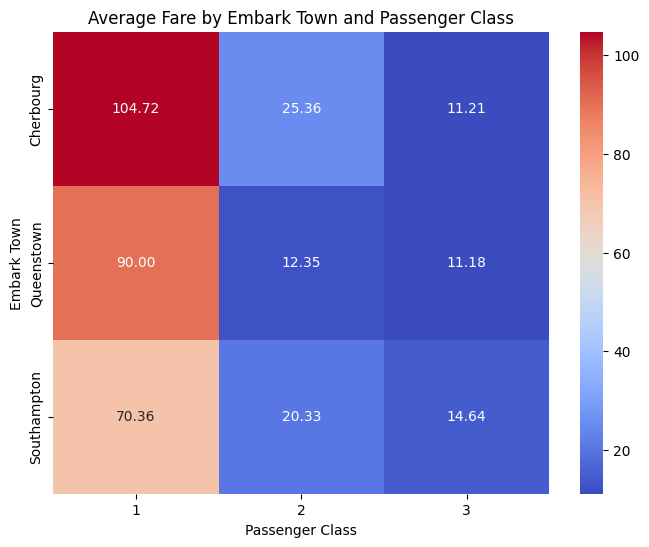

In [20]:
visualizer.ccf_mean_heatmap()

First-class passengers paid significantly higher fares across all embarkation towns, with Cherbourg showing the highest average fares overall.


Second-class fares were notably lower, while third-class fares were the cheapest in every port which we would expect.

### Passenger count by town and class
Creates a heatmap to visualize the passenger count by embarkation town and passenger class.


In [ ]:
def ccf_count_heatmap(self):
    
    # generates the pivot table using the 'ccf_categorization_count' method from the Analyzer class
    # The pivot table contains the passenger count grouped by embarked town and passenger class.
    pivot_table_count = self.ccf_categorization_count()

    plt.figure(figsize = (8,6))  # creates a new figure
    sns.heatmap(pivot_table_count, annot=True, fmt=".2f", cmap="coolwarm") # creates a heatmap to visualize the passenger count, annot = True to
    # display the values inside the cells
    
    plt.title("Passenger Count by Embark Town and Passenger Class")  # adds a title
    plt.xlabel("Passenger Class")  # labels the x-axis
    plt.ylabel("Embark Town")  # labels the y-axis
    plt.show()  # displays the heatmap

##### Notes:
This method uses the pivot table generated by the method `ccf_categorization_count` from the Analyzer class.

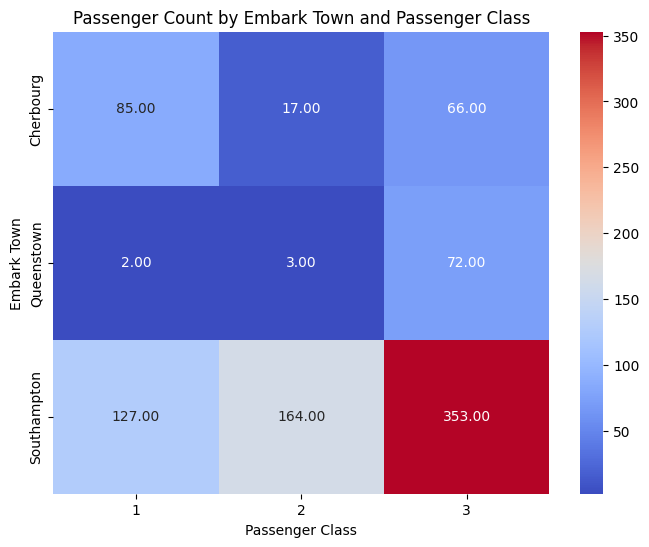

In [22]:
visualizer.ccf_count_heatmap()

Southampton contributed by far the largest number of passengers overall, particularly in third class. 

Cherbourg had more first-class passengers than second or third, while Queenstown had very few first- or second-class travelers but a notable third-class group. 

This distribution indicates that third-class tickets were especially popular at Southampton, whereas Cherbourg attracted more affluent travelers.

### Contingency Heatmap
Creates a heatmap to visualize the contingency table between two categorical variables.



In [ ]:
def plot_contingency_heatmap(self, column1: str, column2: str):
     
    # check if the passed columns exist in the dataset
    assert column1 in self.data.columns, f"Column '{column1}' does not exist in the dataset."
    assert column2 in self.data.columns, f"Column '{column2}' does not exist in the dataset."
        
    # generates a contingency table for every combination of values between column1 and column2
    contingency_table = pd.crosstab(self.data[column1], self.data[column2])
        
    plt.figure(figsize=(8, 6))  # creates a new figure
    sns.heatmap(contingency_table, annot=True, cmap="coolwarm", fmt="d") # generates a heatmap to visualize the relationship 
    # between two categorical variables, annot = True to display the frequencies inside the cells
    
    plt.title(f'Contingency Table: {column1} vs {column2}')  # adds a title
    plt.xlabel(column2)  # labels the x-axis with the name of column2
    plt.ylabel(column1)  # labels the y-axis with the name of column1
    plt.show()  # displays the heatmap

##### Parameters:
column1: str

- The name of the first column to analyze.
- This should be a categorical variable.

column2: str

- The name of the second column to analyze.
- This should also be a categorical variable.

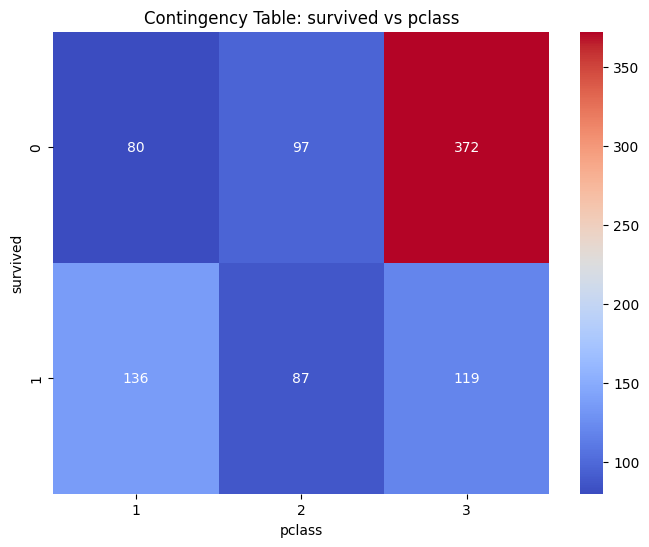

In [24]:
visualizer.plot_contingency_heatmap(column1 = "survived", column2 = "pclass")

In the first class, more passengers survived (136) than died (80). In contrast, in the third class, over three times as many passengers died (372) compared to those who survived (119).

This heatmap illustrates a strong relationship between passenger class and survival rates: passenger in the first class had the highest chances of survival.

### Scatterplot
Creates a scatterplot to visualize the relationship between two numerical variables.

> Uses the `chi_square_test` function




In [ ]:
def basic_scatterplot(self, column1: str, column2: str):

    # check if the passed columns exist in the dataset
    assert column1 in self.data.columns, f"Column '{column1}' does not exist in the dataset."
    assert column2 in self.data.columns, f"Column '{column2}' does not exist in the dataset."
        
    plt.figure(figsize=(10, 6))  # creates a new figure
    sns.regplot(x = column1, y = column2, data=data, scatter_kws={'alpha': 0.5}) # generates a scatterplot using seaborn, scatter_kws={'alpha': 0.5} 
    # sets transparency of points to 0.5 for better visualization
    plt.yscale('log')  # makes the y-axis logarithmic

    fare_ticks = [1, 5, 10, 20, 50, 100, 200, 500]  # example values (ticket prices) # for better visualization
    plt.yticks(fare_ticks, fare_ticks)
    
    plt.title(f"Scatterplot of {column1} vs {column2}")  # adds title
    plt.xlabel(column1)  # adds label to the x-axis using the name of column1
    plt.ylabel(column2)  # adds label to the y-axis using the name of column2
    plt.show()  # displays the scatterplot

##### Parameters:
column1: str
- The name of the column that is used for the x-axis. This should be a numerical variable.

column2: str
- The name of the column that is used for the y-axis. This should also be a numerical variable.

##### Notes:
The y-axis is set to a logarithmic scale. 
alpha = 0.5 is used for better visibility of the scatter points

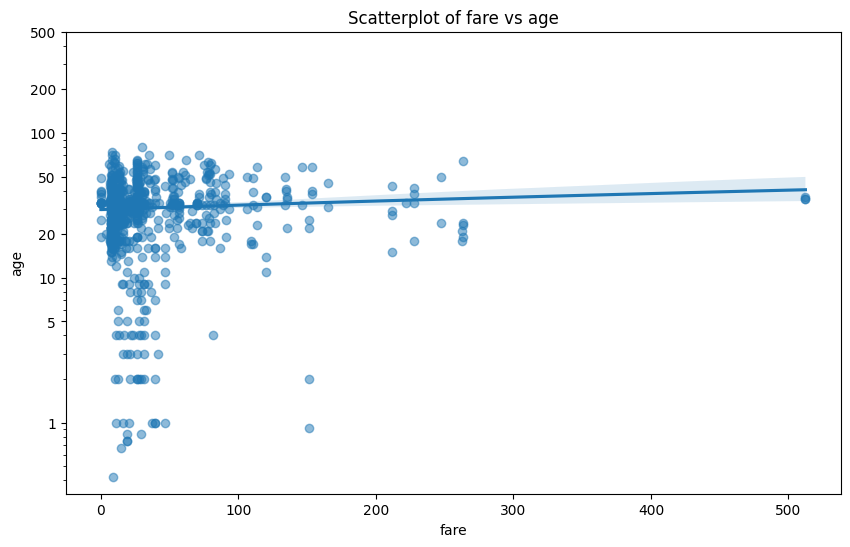

In [26]:
visualizer.basic_scatterplot(column1= "fare", column2= "age")

The scatterplot shows a slight positive correlation between fare and age. However, the majority of passengers paid lower fares regardless of their age which can be explained by the high proportion of passengers in the third class (associated with lower fares).

A few outliers paid significantly higher fares, though this does not appear to be strongly linked to older passengers.

### Sorted by Scatterplot
Creates a scatterplot to visualize the relationship between two
numerical variables grouped by a categorical variable.



In [ ]:
def scatterplot_sorted_by(self, column1: str, column2: str, hue: str):
    
    # check if the passed columns exist in the dataset
    assert column1 in self.data.columns, f"Column '{column1}' does not exist in the dataset."
    assert column2 in self.data.columns, f"Column '{column2}' does not exist in the dataset."
    assert hue in self.data.columns, f"Column '{hue}' does not exist in the dataset."
       
    sns.lmplot(x = column1, y = column2, data=data, hue = hue, aspect=1.5, scatter_kws={'alpha': 0.5}) # generates a scatterplot using seaborn, 
    # scatter_kws={'alpha': 0.5} sets transparency of points to 0.5 for better visualization
    plt.yscale('log')  # makes the y-axis logarithmic

    fare_ticks = [1, 5, 10, 20, 50, 100, 200, 500]  # example values (ticket prices) for better visualization
    plt.yticks(fare_ticks, fare_ticks)  # setting the ticks for the y axis
    
    plt.title(f"Scatterplot of {column1} vs {column2} by {hue}")  # adds title
    plt.xlabel(column1)  # adds label to the x-axis using the name of column1
    plt.ylabel(column2)  # adds label to the y-axis using the name of column2
    plt.show()  # displays the scatterplot

##### Parameters:
column1: str
- The name of the column that is used for the x-axis. This should be a numerical variable.


column2: str
- The name of the column that is used for the y-axis. This should also be a numerical variable.


hue: str
- The name of the column representing the groups. This should be a categorical variable.

##### Notes:
The y-axis is set to a logarithmic scale.

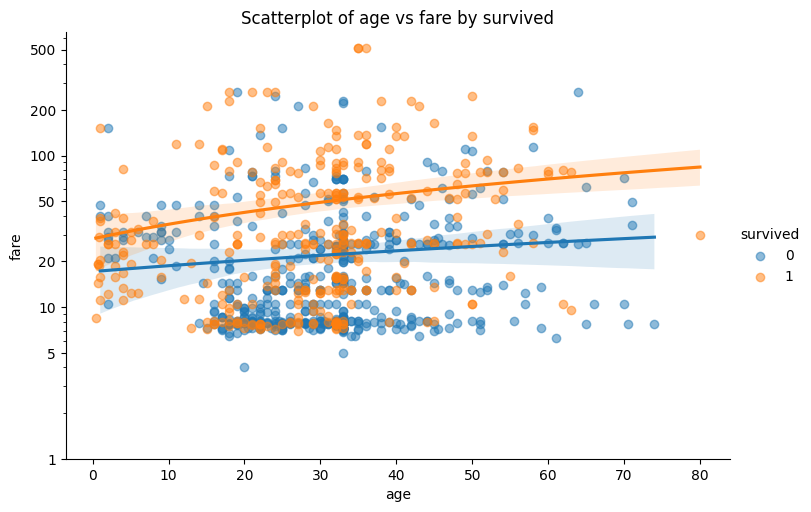

In [32]:
visualizer.scatterplot_sorted_by(column1= "age", column2= "fare", hue= "survived")

Survivors tend to have higher fares across most age groups, suggesting a relationship between higher ticket prices(and therefore a higher passenger class) and increased survival. 

Both groups show a slight positive correlation between age and fare, but non-survivors are clustered more heavily in the lower fare range.